# RoadGuardian AI

## Notebook 02

# Data Preprocessing for CNN

This notebook prepares the RDD2022 dataset for CNN training.

Steps

- Read Images
- Read Labels
- Convert Labels
- Crop Damage Region
- Resize Images
- Normalize Images
- Data Augmentation
- TensorFlow Dataset

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder

In [4]:
train_images = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images"

train_labels = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels"

val_images = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images"

val_labels = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels"

In [8]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/aliabdelmenam
/kaggle/input/datasets/aliabdelmenam/rdd-2022
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test/labels
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test/images
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images


In [9]:
print("Training Images :", len(os.listdir(train_images)))
print("Training Labels :", len(os.listdir(train_labels)))

print()

print("Validation Images :", len(os.listdir(val_images)))
print("Validation Labels :", len(os.listdir(val_labels)))

Training Images : 26869
Training Labels : 26869

Validation Images : 5758
Validation Labels : 5758


In [22]:
print(train_images)
print(train_labels)

print(val_images)
print(val_labels)

/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels


In [23]:
image_name = os.listdir(train_images)[0]

print(image_name)

India_000594.jpg


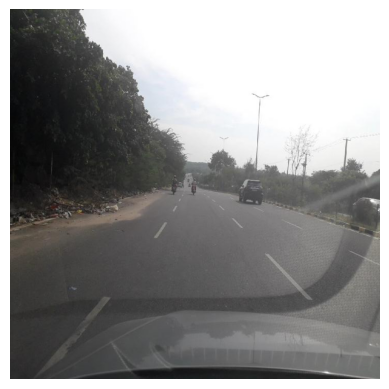

In [24]:
image_path = os.path.join(train_images, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [25]:
print("Height :", image.shape[0])
print("Width :", image.shape[1])
print("Channels :", image.shape[2])

Height : 720
Width : 720
Channels : 3


In [26]:
label_name = image_name.replace(".jpg", ".txt")

print(label_name)

India_000594.txt


In [27]:
label_file = os.path.join(train_labels, label_name)

print(label_file)
print(os.path.exists(label_file))

/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels/India_000594.txt
True


In [28]:
with open(label_file, "r") as f:
    print(f.read())

In [29]:
for file in os.listdir(train_labels):

    path = os.path.join(train_labels, file)

    if os.path.getsize(path) > 0:

        print(file)

        break

Norway_007787.txt


In [31]:
label_file = os.path.join(train_labels, file)

with open(label_file, "r") as f:

    print(f.read())

4 0.817127 0.709031 0.021159 0.020988
4 0.704079 0.637361 0.054647 0.026727
4 0.769168 0.777882 0.023038 0.020988
4 0.600114 0.665908 0.014512 0.013361
4 0.672612 0.706935 0.019592 0.013410
4 0.747222 0.747167 0.026449 0.012241
4 0.735597 0.654572 0.087753 0.037657
4 0.645348 0.701103 0.012734 0.018077



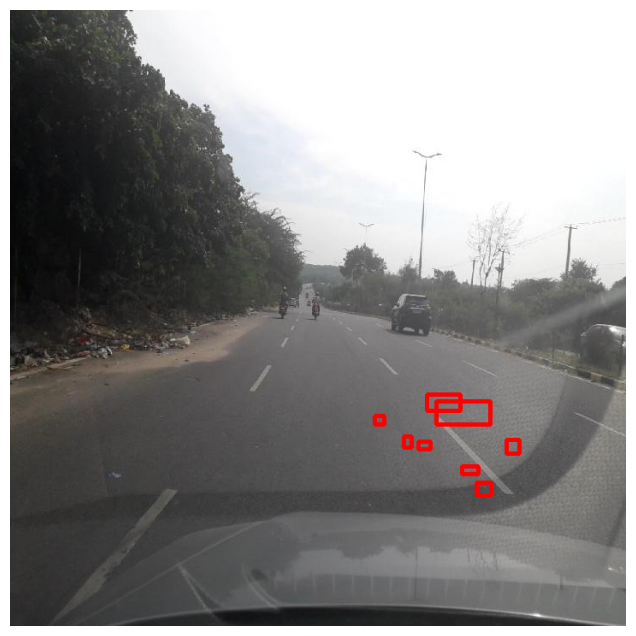

In [32]:
import cv2
import matplotlib.pyplot as plt

image_path = os.path.join(train_images, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

with open(label_file, "r") as f:
    for line in f.readlines():

        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)

        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(image,
                      (x1, y1),
                      (x2, y2),
                      (255,0,0),
                      4)

plt.figure(figsize=(12,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [33]:
print("="*50)

print("Dataset Ready For CNN Training")

print("Total Training Images :", len(os.listdir(train_images)))
print("Total Validation Images :", len(os.listdir(val_images)))

print("\nClasses")

print("0 -> Longitudinal Crack")
print("1 -> Transverse Crack")
print("2 -> Alligator Crack")
print("3 -> Pothole")
print("4 -> Repair / Other")

print("="*50)

Dataset Ready For CNN Training
Total Training Images : 26869
Total Validation Images : 5758

Classes
0 -> Longitudinal Crack
1 -> Transverse Crack
2 -> Alligator Crack
3 -> Pothole
4 -> Repair / Other


In [34]:
def read_labels(label_path):

    boxes=[]

    with open(label_path,"r") as f:

        lines=f.readlines()

        for line in lines:

            values=line.strip().split()

            if len(values)==5:

                cls=int(values[0])

                x=float(values[1])

                y=float(values[2])

                w=float(values[3])

                h=float(values[4])

                boxes.append([cls,x,y,w,h])

    return boxes

In [35]:
boxes=read_labels(label_file)

print("Total Bounding Boxes :",len(boxes))

boxes[:5]

Total Bounding Boxes : 8


[[4, 0.817127, 0.709031, 0.021159, 0.020988],
 [4, 0.704079, 0.637361, 0.054647, 0.026727],
 [4, 0.769168, 0.777882, 0.023038, 0.020988],
 [4, 0.600114, 0.665908, 0.014512, 0.013361],
 [4, 0.672612, 0.706935, 0.019592, 0.01341]]

In [36]:
image_path=os.path.join(train_images,image_name)

image=cv2.imread(image_path)

image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

H,W,_=image.shape

pixel_boxes=[]

for box in boxes:

    cls,x,y,w,h=box

    x1=int((x-w/2)*W)

    y1=int((y-h/2)*H)

    x2=int((x+w/2)*W)

    y2=int((y+h/2)*H)

    pixel_boxes.append([cls,x1,y1,x2,y2])

pixel_boxes[:5]

[[4, 580, 502, 595, 518],
 [4, 487, 449, 526, 468],
 [4, 545, 552, 562, 567],
 [4, 426, 474, 437, 484],
 [4, 477, 504, 491, 513]]

In [38]:
class_names = {
    0: "Longitudinal Crack",
    1: "Transverse Crack",
    2: "Alligator Crack",
    3: "Pothole",
    4: "Repair / Other"
}

print(class_names)

{0: 'Longitudinal Crack', 1: 'Transverse Crack', 2: 'Alligator Crack', 3: 'Pothole', 4: 'Repair / Other'}


In [39]:
print(type(class_names))
print(class_names)

<class 'dict'>
{0: 'Longitudinal Crack', 1: 'Transverse Crack', 2: 'Alligator Crack', 3: 'Pothole', 4: 'Repair / Other'}


In [40]:
print(type(pixel_boxes))
print(len(pixel_boxes))

<class 'list'>
8


In [41]:
print(image.shape)

(720, 720, 3)


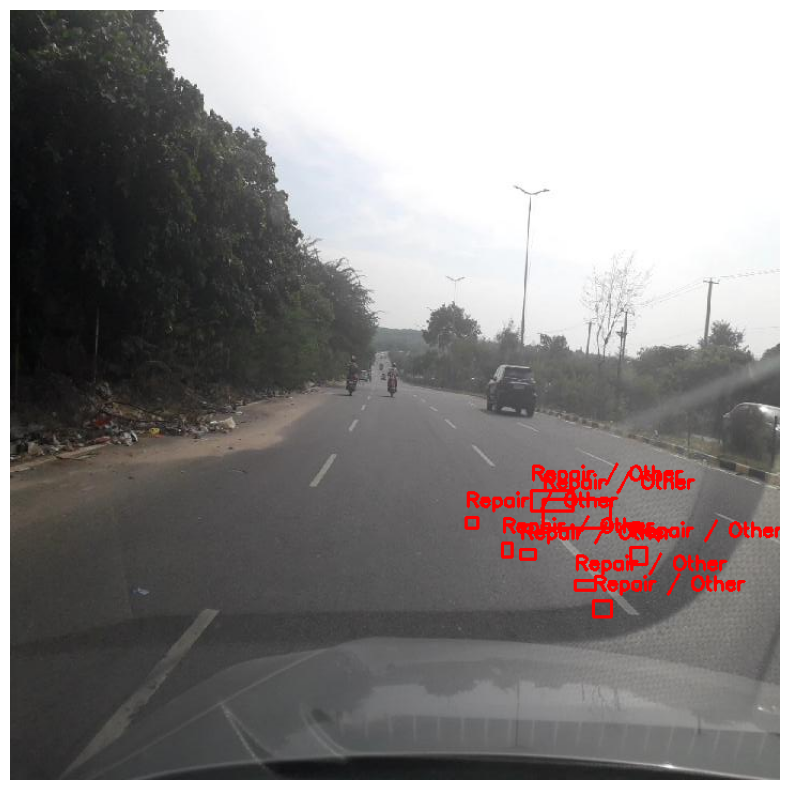

In [42]:
image_copy = image.copy()

for box in pixel_boxes:

    cls, x1, y1, x2, y2 = box

    # Bounding Box
    cv2.rectangle(
        image_copy,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Class Name
    cv2.putText(
        image_copy,
        class_names[int(cls)],
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image_copy)
plt.axis("off")
plt.show()

In [43]:
cropped_images = []
cropped_labels = []

for box in pixel_boxes:

    cls, x1, y1, x2, y2 = box

    # Image ke bahar na jaye
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    crop = image[y1:y2, x1:x2]

    if crop.size > 0:
        cropped_images.append(crop)
        cropped_labels.append(cls)

print("Total Cropped Images :", len(cropped_images))

Total Cropped Images : 8


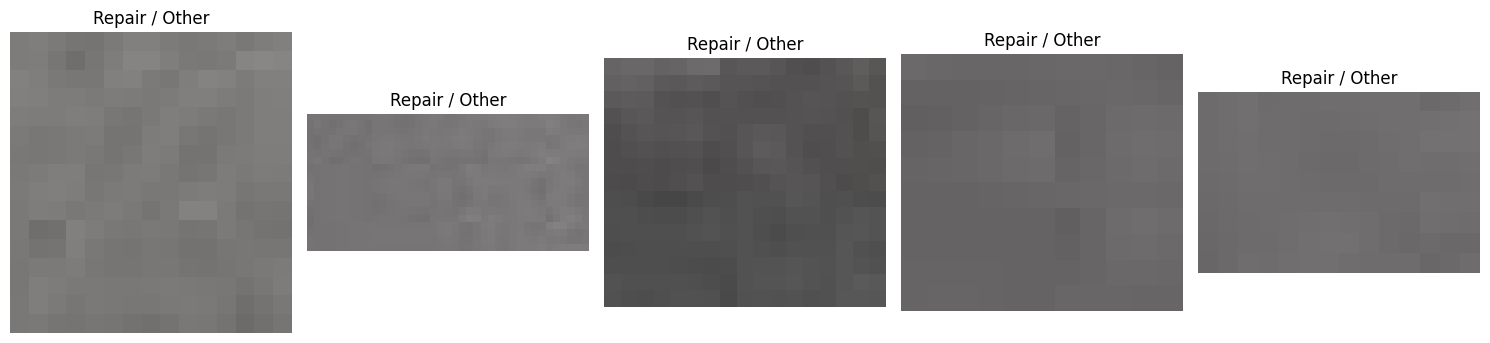

In [44]:
plt.figure(figsize=(15,5))

for i in range(min(5, len(cropped_images))):

    plt.subplot(1,5,i+1)

    plt.imshow(cropped_images[i])

    plt.title(class_names[cropped_labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [45]:
IMG_SIZE = 224

resized_images = []

for img in cropped_images:

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    resized_images.append(img)

print("Total Resized Images :", len(resized_images))

Total Resized Images : 8


In [46]:
X = np.array(resized_images, dtype=np.float32) / 255.0

y = np.array(cropped_labels)

print("Images Shape :", X.shape)

print("Labels Shape :", y.shape)

Images Shape : (8, 224, 224, 3)
Labels Shape : (8,)


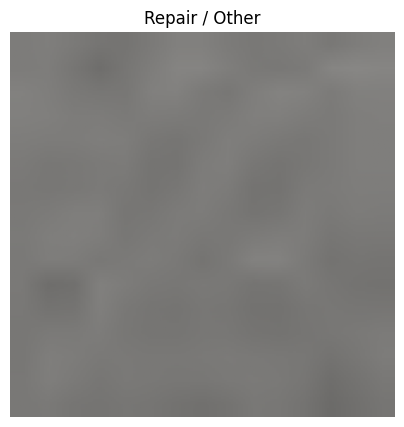

In [47]:
plt.figure(figsize=(5,5))

plt.imshow(X[0])

plt.title(class_names[int(y[0])])

plt.axis("off")

plt.show()

In [48]:
print("="*60)

print("CNN PREPROCESSING COMPLETED")

print()

print("Image Size :", IMG_SIZE)

print("Processed Images :", len(X))

print("Processed Labels :", len(y))

print()

print("Dataset is Ready for CNN Training")

print("="*60)

CNN PREPROCESSING COMPLETED

Image Size : 224
Processed Images : 8
Processed Labels : 8

Dataset is Ready for CNN Training


In [49]:
IMG_SIZE = 224

print("Image Size :", IMG_SIZE)

Image Size : 224


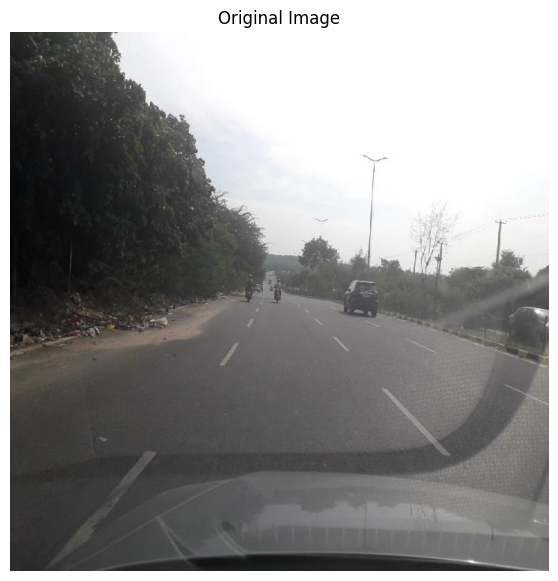

In [50]:
sample_image = cv2.imread(image_path)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,7))
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

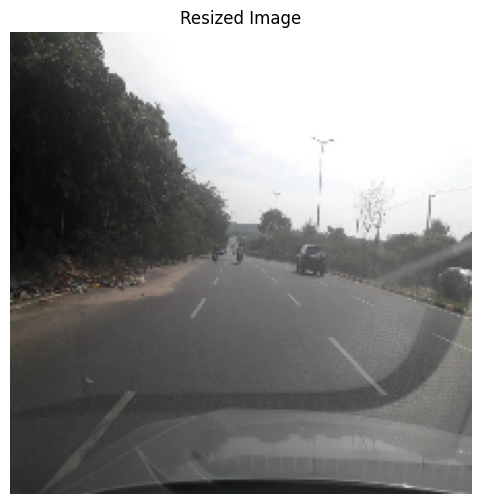

In [51]:
resized = cv2.resize(sample_image,(IMG_SIZE,IMG_SIZE))

plt.figure(figsize=(6,6))
plt.imshow(resized)
plt.title("Resized Image")
plt.axis("off")
plt.show()

In [52]:
normalized = resized/255.0

print(normalized.min())
print(normalized.max())

0.0196078431372549
1.0


In [53]:
print("Original Shape :",sample_image.shape)
print("Resized Shape :",resized.shape)

Original Shape : (720, 720, 3)
Resized Shape : (224, 224, 3)


In [54]:
image_array=np.array(normalized)

print(type(image_array))
print(image_array.shape)

<class 'numpy.ndarray'>
(224, 224, 3)


In [55]:
print(image_array.dtype)

float64


In [56]:
print("Total Pixels :",image_array.size)
print("Memory :",image_array.nbytes/1024,"KB")

Total Pixels : 150528
Memory : 1176.0 KB


# Image Preprocessing Summary

✔ Images resized to 224×224

✔ Pixel values normalized

✔ Ready for CNN model

✔ Tensor conversion completed

# Notebook 2 Completed

Completed Tasks

✔ Read Images

✔ Read Labels

✔ Bounding Box Visualization

✔ Image Resize

✔ Image Normalization

✔ CNN Input Preparation

Next Notebook:

Notebook 3 → CNN Model Training